In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
import warnings
from scipy.optimize import least_squares
import numpy.linalg as la

In [2]:
data = {
    '45': {
        'time': np.array([0., 2., 4., 8., 16., 32., 64.]),
        'Al_f': np.array([0.57793934, 0.44606673, 0.35159301, 0.30447279,
                          0.19025257, 0.1190359, 0.0683903]),
        'Al_tot': 0.7539061007838296
    },
    '22': {
        'time': np.array([0., 1., 1.5, 2., 4., 6., 8., 12., 16., 22.]),
        'Al_f': np.array([1.06360903, 0.764354, 0.66100065, 0.62858508,
                          0.47474017, 0.37571418, 0.30535558, 0.22266848,
                          0.18058097, 0.1481312]),
        'Al_tot': 1.4662980027207297
    },
    '16': {
        'time': np.array([0., 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 6.5, 10.75]),
        'Al_f': np.array([1.69098957, 0.8527369, 0.56334472, 0.4222341,
                          0.35084747, 0.28044497, 0.29166648, 0.25271929,
                          0.18129413, 0.1560142]),
        'Al_tot': 2.0613851873073203
    }
}

In [3]:
print(len(data['45']['Al_f']))
print(len(data['22']['Al_f']))
print(len(data['16']['Al_f']))
print(len(data['45']['Al_f'])+len(data['22']['Al_f'])+len(data['16']['Al_f']))

7
10
10
27


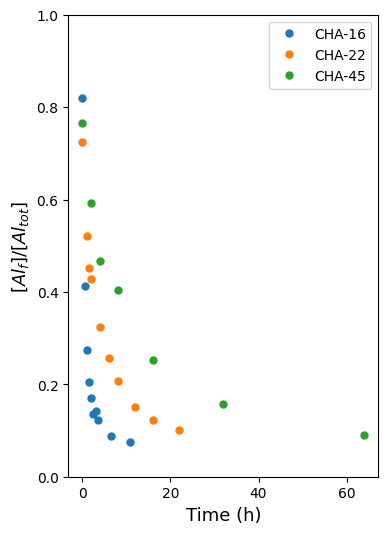

In [4]:
plt.figure(figsize=(4, 6))
plt.plot(data['16']['time'],data['16']['Al_f']/data['16']['Al_tot'],'.', markersize=10,label='CHA-16')
plt.plot(data['22']['time'],data['22']['Al_f']/data['22']['Al_tot'],'.', markersize=10,label='CHA-22')
plt.plot(data['45']['time'],data['45']['Al_f']/data['45']['Al_tot'],'.', markersize=10,label='CHA-45')
plt.ylim(0,1)
plt.xlabel('Time (h)', fontsize=13)
plt.ylabel('$[Al_f]/[Al_{tot}]$', fontsize=13)
# plt.yscale('log')
# plt.ylim(1e-2,1e0)
plt.legend()

In [5]:
def model(t, y, k1, km1, k2, Al_tot):
    Al_f, Al_ex = y
    vac = Al_tot - Al_f  # [*] = Al_tot - Al_f

    dAl_f  = -k1*Al_f + km1*Al_ex*vac
    dAl_ex =  k1*Al_f - km1*Al_ex*vac - 2.0*k2*(Al_ex**2)
    return np.array([dAl_f, dAl_ex], dtype=float)

In [6]:
def simulate_model(params, sial_ratio, rtol=1e-8, atol=1e-10):
    """
    params = (k1, km1, k2) all > 0
    Returns (Al_f_pred, Al_ex_pred) arrays aligned to data time points.
    """
    exp_data = data[sial_ratio]
    t_eval = exp_data['time']
    Al_tot = exp_data['Al_tot']

    # initial condition: Al_f(0)=Al_tot, Al_ex(0)=0
    y0 = np.array([Al_tot, 0.0], dtype=float)

    try:
        sol = solve_ivp(
            fun=lambda t, y: model(t, y, params[0], params[1], params[2], Al_tot),
            t_span=(float(t_eval[0]), float(t_eval[-1])),
            y0=y0,
            t_eval=t_eval,
            method='BDF',
            rtol=rtol,
            atol=atol
        )

        if (not sol.success) or np.any(~np.isfinite(sol.y)):
            return None, None

        return sol.y[0], sol.y[1]

    except Exception:
        return None, None

In [7]:
def residuals(params, rtol=1e-8, atol=1e-10, penalty=1e3):
    res_list = []

    for sial in ['45', '22', '16']:
        Al_f_pred, Al_ex_pred = simulate_model(params, sial, rtol=rtol, atol=atol)
        if Al_f_pred is None:
            res_list.append(penalty * np.ones_like(data[sial]['Al_f'], dtype=float))
            continue

        Al_f_exp = data[sial]['Al_f']
        res_list.append(Al_f_pred - Al_f_exp)

    return np.concatenate(res_list)

In [8]:
# ---- choose a reasonable starting guess ----
# Example: start near k1=1, km1=1, k2=1 in your units
params0 = np.array([1, 1, 1], dtype=float)

lb = np.array([1e-4, 1e-4, 1e-4], dtype=float)
ub = np.array([1e4,  1e4,  1e4], dtype=float)

res = least_squares(
    fun=lambda p: residuals(p, rtol=1e-8, atol=1e-10),
    x0=params0,
    bounds=(lb, ub),
    method="trf",
    jac="3-point",     # '3-point' more accurate than '2-point' citeturn0search1
    max_nfev=200       # increase if needed
)

x_hat = res.x

print("Optimization success:", res.success)
print("Message:", res.message)
print("params_hat = [k1, km1, k2] =", x_hat)
print("SSE (sum of squared residuals):", 2.0 * res.cost)  # res.cost = 0.5*||r||^2

Optimization success: True
Message: `ftol` termination condition is satisfied.
params_hat = [k1, km1, k2] = [38.66744598 43.57987298  1.04549215]
SSE (sum of squared residuals): 1.1693339852759013


In [9]:
def compute_degeneracy_metrics_from_ls_result(ls_result, eig_floor=1e-300):
    """
    Returns:
      J, A, eigvals, kappa(A), N(A)=log10(kappa(A))
    """
    J = np.asarray(ls_result.jac, dtype=float)  # shape: (m_residuals, n_params)

    A = J.T @ J

    # symmetric eigenvalues
    eigvals = la.eigvalsh(A)  # uses symmetry citeturn0search2
    eigvals = np.maximum(eigvals, eig_floor)

    kappa = float(eigvals.max() / eigvals.min())
    N_A = float(np.log10(kappa))

    return J, A, eigvals, kappa, N_A

In [10]:
J, A, eigvals, kappaA, NA = compute_degeneracy_metrics_from_ls_result(res)

print("Eigenvalues of A=J^T J:", eigvals)
print("Condition number kappa(A):", kappaA)
print("Degree of degeneracy N(A)=log10(kappa(A)):", NA)

Eigenvalues of A=J^T J: [7.55582569e-10 2.46894397e-05 4.81200994e-01]
Condition number kappa(A): 636860899.4105268
Degree of degeneracy N(A)=log10(kappa(A)): 8.804044585843545


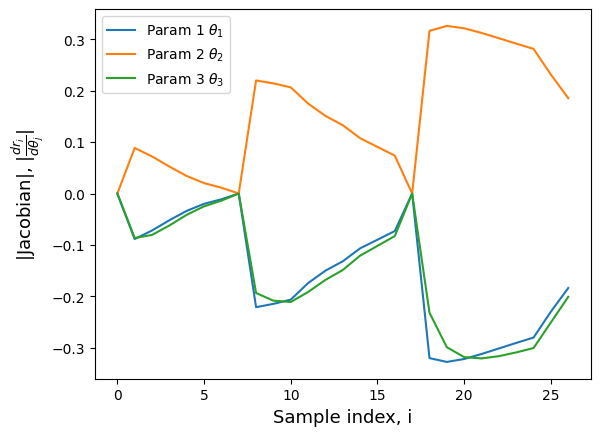

In [11]:
Jnorm = J / np.linalg.norm(J, axis=0, keepdims=True)
plt.plot(np.arange(len(Jnorm[:,0])),Jnorm[:,0],label=r'Param 1 $\theta_1$')
plt.plot(np.arange(len(Jnorm[:,0])),Jnorm[:,1],label=r'Param 2 $\theta_2$')
plt.plot(np.arange(len(Jnorm[:,0])),Jnorm[:,2],label=r'Param 3 $\theta_3$')
plt.xlabel('Sample index, i',fontsize=13)
plt.ylabel(r'|Jacobian|, $|\frac{dr_i}{d\theta_j}|$',fontsize=13)
plt.legend()

In [12]:
eigvals, eigvecs = np.linalg.eigh(A)
print("eigvals =", eigvals)
print("eigvecs =\n", eigvecs)

eigvals = [7.55582622e-10 2.46894397e-05 4.81200994e-01]
eigvecs =
 [[ 0.64084148  0.76614512 -0.04841328]
 [ 0.76767163 -0.63943551  0.04245586]
 [ 0.00157018 -0.06437298 -0.99792467]]


In [13]:
def params_to_log(params):
    k1, km1, k2 = np.asarray(params, dtype=float)
    return np.array([np.log10(k1), np.log10(km1), np.log10(k2)])

def log_to_params(logs):
    logk1, logkm1, logk2 = np.asarray(logs, dtype=float)
    return np.array([10**logk1, 10**logkm1, 10**logk2])

def residuals_logs(log, rtol=1e-8, atol=1e-10, penalty=1e3):
    params = log_to_params(log)
    res_list = []

    for sial in ['45', '22', '16']:
        Al_f_pred, Al_ex_pred = simulate_model(params, sial, rtol=rtol, atol=atol)
        Al_f_exp = data[sial]['Al_f']
        res_list.append(Al_f_pred - Al_f_exp)

    return np.concatenate(res_list)

In [15]:
# ---- choose a reasonable starting guess ----
# Example: start near k1=1, km1=1, k2=1 in your units
params0 = np.array([5.222518e-01, 3.616851e-01, 4.535391e-02], dtype=float)
logs0 = params_to_log(params0)

lb = np.array([-2, -2, -3], dtype=float)
ub = np.array([0,  0,  0], dtype=float)

res = least_squares(
    fun=lambda l: residuals_logs(l, rtol=1e-8, atol=1e-10),
    x0=logs0,
    bounds=(lb, ub),
    method="trf",
    jac="3-point",     # '3-point' more accurate than '2-point' citeturn0search1
    max_nfev=200       # increase if needed
)

log_hat = res.x
param_hat = log_to_params(log_hat)

print("Optimization success:", res.success)
print("Message:", res.message)
print("params_hat = [k1, km1, k2] =", param_hat)
print("SSE (sum of squared residuals):", 2.0 * res.cost)  # res.cost = 0.5*||r||^2

Optimization success: True
Message: `ftol` termination condition is satisfied.
params_hat = [k1, km1, k2] = [1.         0.13136226 0.01632313]
SSE (sum of squared residuals): 1.2986903407141224


In [16]:
J, A, eigvals, kappaA, NA = compute_degeneracy_metrics_from_ls_result(res)

print("Eigenvalues of A=J^T J:", eigvals)
print("Condition number kappa(A):", kappaA)
print("Degree of degeneracy N(A)=log10(kappa(A)):", NA)

Eigenvalues of A=J^T J: [6.38561817e-06 2.93468045e-02 2.06452889e+01]
Condition number kappa(A): 3233091.6727838586
Degree of degeneracy N(A)=log10(kappa(A)): 6.509618019000584


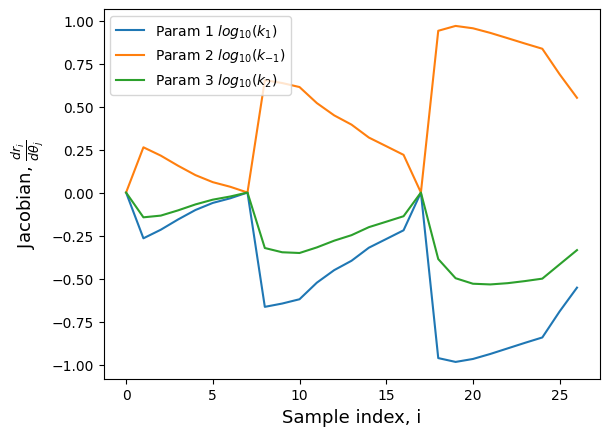

In [17]:
# Jnorm = J / np.linalg.norm(J, axis=0, keepdims=True)
plt.plot(np.arange(len(J[:,0])),J[:,0],label=r'Param 1 $log_{10}(k_1)$')
plt.plot(np.arange(len(J[:,0])),J[:,1],label=r'Param 2 $log_{10}(k_{-1})$')
plt.plot(np.arange(len(J[:,0])),J[:,2],label=r'Param 3 $log_{10}(k_2)$')
plt.xlabel('Sample index, i',fontsize=13)
plt.ylabel(r'Jacobian, $\frac{dr_i}{d\theta_j}$',fontsize=13)
plt.legend()

In [18]:
eigvals, eigvecs = np.linalg.eigh(A)
print("eigvals =", eigvals)
print("eigvecs =\n", eigvecs)

eigvals = [6.38561817e-06 2.93468045e-02 2.06452889e+01]
eigvecs =
 [[ 0.68472067 -0.30454287 -0.6621263 ]
 [ 0.72633342  0.21038372  0.65435347]
 [ 0.05997809  0.9289738  -0.36525375]]


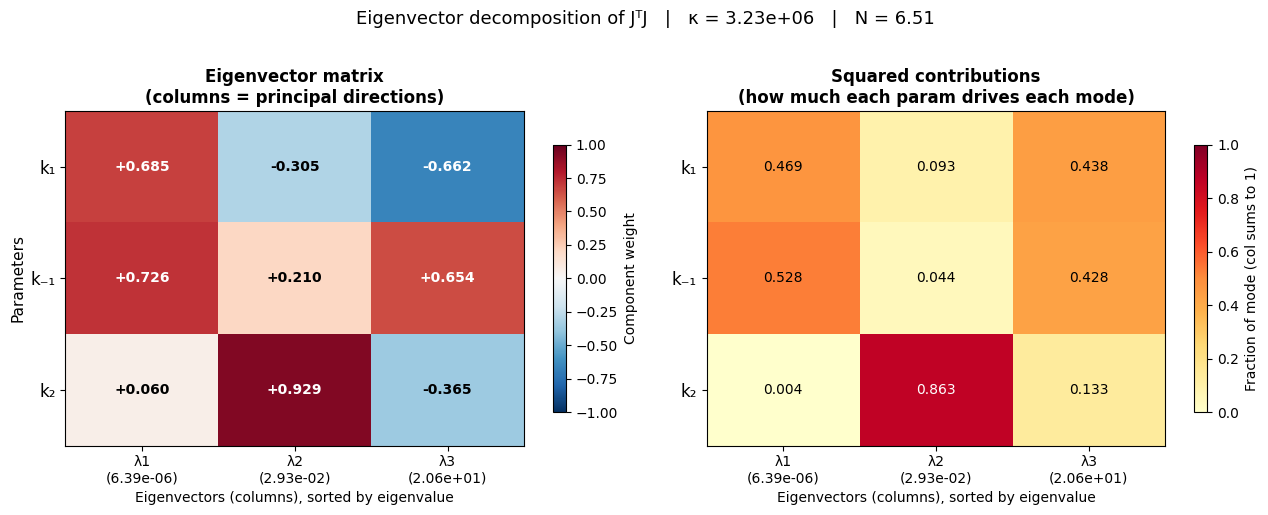

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import linalg as la

# --- Compute ---
J, A, eigvals, kappa, N_A = compute_degeneracy_metrics_from_ls_result(res)
eigvals_sorted, eigvecs_sorted = np.linalg.eigh(A)  # ascending order

param_names  = ['k₁', 'k₋₁', 'k₂']
eigvec_labels = [f'λ{i+1}\n({v:.2e})' for i, v in enumerate(eigvals_sorted)]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw eigenvector matrix
im0 = axes[0].imshow(eigvecs_sorted, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Component weight')
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(eigvec_labels, fontsize=10)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(param_names, fontsize=12)
axes[0].set_xlabel('Eigenvectors (columns), sorted by eigenvalue', fontsize=10)
axes[0].set_ylabel('Parameters', fontsize=11)
axes[0].set_title('Eigenvector matrix\n(columns = principal directions)', fontsize=12, fontweight='bold')

for i in range(3):
    for j in range(3):
        val = eigvecs_sorted[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        axes[0].text(j, i, f'{val:+.3f}', ha='center', va='center',
                     fontsize=10, color=color, fontweight='bold')

# Right: squared contributions (variance explained per param per mode)
contrib = eigvecs_sorted**2   # each column sums to 1
im1 = axes[1].imshow(contrib, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='Fraction of mode (col sums to 1)')
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(eigvec_labels, fontsize=10)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(param_names, fontsize=12)
axes[1].set_xlabel('Eigenvectors (columns), sorted by eigenvalue', fontsize=10)
axes[1].set_title('Squared contributions\n(how much each param drives each mode)', fontsize=12, fontweight='bold')

for i in range(3):
    for j in range(3):
        val = contrib[i, j]
        color = 'white' if val > 0.6 else 'black'
        axes[1].text(j, i, f'{val:.3f}', ha='center', va='center',
                     fontsize=10, color=color)

plt.suptitle(f'Eigenvector decomposition of JᵀJ   |   κ = {kappa:.2e}   |   N = {N_A:.2f}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eigenvector_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
def params_to_theta(params):
    """
    params = (k1, km1, k2) all > 0
    theta = (log10K, log10s, log10k2)
    """
    k1, km1, k2 = np.asarray(params, dtype=float)
    K = k1 / km1
    s = np.sqrt(k1 * km1)
    return np.array([np.log10(K), np.log10(s), np.log10(k2)], dtype=float)
    
def theta_to_params(theta):
    """
    theta = [log10K, log10s, log10k2]
    returns params = (k1, km1, k2)
    """
    log10K, log10s, log10k2 = np.asarray(theta, dtype=float)

    K  = 10**log10K
    s  = 10**log10s
    k2 = 10**log10k2

    sqrtK = np.sqrt(K)
    k1  = s * sqrtK
    km1 = s / sqrtK

    return np.array([k1, km1, k2], dtype=float)

In [20]:
def residuals_theta(theta, rtol=1e-8, atol=1e-10, penalty=1e3):
    """
    Residual vector for least_squares in theta-space.

    Returns: concatenated residuals [Al_f_pred - Al_f_exp] across all datasets.
    """
    params = theta_to_params(theta)

    # # enforce positivity (theta_to_params already ensures this, but keep safety)
    # if np.any(~np.isfinite(params)) or np.any(params <= 0):
    #     # return a large residual vector
    #     n = sum(len(data[s]['time']) for s in ['45', '22', '16'])
    #     return penalty * np.ones(n, dtype=float)

    res_list = []

    for sial in ['45', '22', '16']:
        Al_f_pred, Al_ex_pred = simulate_model(params, sial, rtol=rtol, atol=atol)
        if Al_f_pred is None:
            res_list.append(penalty * np.ones_like(data[sial]['Al_f'], dtype=float))
            continue

        Al_f_exp = data[sial]['Al_f']
        res_list.append(Al_f_pred - Al_f_exp)

    return np.concatenate(res_list)


In [21]:
# ---- choose a reasonable starting guess ----
# Example: start near k1=1, km1=1, k2=1 in your units
params0 = np.array([1, 1, 1], dtype=float)
theta0 = params_to_theta(params0)

# ---- bounds in theta-space ----
# If you previously used k in [1e-4,1e5] and k2 in [1e-7,1e4], then:
# K = k1/km1 in [1e-9, 1e9]  -> log10K in [-9, 9]
# s = sqrt(k1*km1) in [1e-4, 1e5] -> log10s in [-4, 5]
# k2 in [1e-7, 1e4] -> log10k2 in [-7, 4]
lb = np.array([-4.0, -4.0, -4.0], dtype=float)
ub = np.array([ 4.0,  4.0,  4.0], dtype=float)

res = least_squares(
    fun=lambda th: residuals_theta(th, rtol=1e-8, atol=1e-10),
    x0=theta0,
    bounds=(lb, ub),
    method="trf",
    jac="3-point",     # '3-point' more accurate than '2-point' citeturn0search1
    max_nfev=200       # increase if needed
)

theta_hat = res.x
params_hat = theta_to_params(theta_hat)  # [k1, km1, k2]

print("Optimization success:", res.success)
print("Message:", res.message)
print("theta_hat = [log10K, log10s, log10k2] =", theta_hat)
print("params_hat = [k1, km1, k2] =", params_hat)
print("SSE (sum of squared residuals):", 2.0 * res.cost)  # res.cost = 0.5*||r||^2


Optimization success: True
Message: `ftol` termination condition is satisfied.
theta_hat = [log10K, log10s, log10k2] = [-0.05239441  1.63404284  0.01968391]
params_hat = [k1, km1, k2] = [40.53644253 45.73409009  1.0463667 ]
SSE (sum of squared residuals): 1.1693338394720063


In [22]:
J, A, eigvals, kappaA, NA = compute_degeneracy_metrics_from_ls_result(res)

print("Eigenvalues of A=J^T J:", eigvals)
print("Condition number kappa(A):", kappaA)
print("Degree of degeneracy N(A)=log10(kappa(A)):", NA)


Eigenvalues of A=J^T J: [1.23855794e-05 2.60025293e-02 1.17035643e+01]
Condition number kappa(A): 944934.7473256786
Degree of degeneracy N(A)=log10(kappa(A)): 5.975401819244884


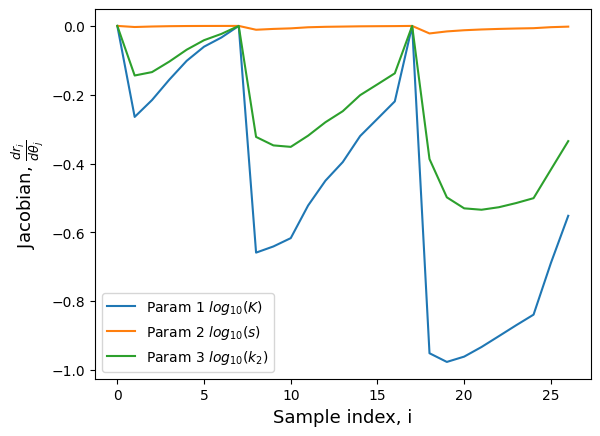

In [23]:
# Jnorm = J / np.linalg.norm(J, axis=0, keepdims=True)
plt.plot(np.arange(len(J[:,0])),J[:,0],label=r'Param 1 $log_{10}(K)$')
plt.plot(np.arange(len(J[:,0])),J[:,1],label=r'Param 2 $log_{10}(s)$')
plt.plot(np.arange(len(J[:,0])),J[:,2],label=r'Param 3 $log_{10}(k_2)$')
plt.xlabel('Sample index, i',fontsize=13)
plt.ylabel(r'Jacobian, $\frac{dr_i}{d\theta_j}$',fontsize=13)
plt.legend()

In [24]:
for j in range(J.shape[1]):
    for k in range(j+1, J.shape[1]):
        c = np.dot(J[:, j], J[:, k]) / (np.linalg.norm(J[:, j]) * np.linalg.norm(J[:, k]))
        print(j, k, c)

0 1 0.9118199170626093
0 2 0.9939285868938869
1 2 0.8622542099405037


In [25]:
eigvals, eigvecs = np.linalg.eigh(A)
print("eigvals =", eigvals)
print("eigvecs =\n", eigvecs)

eigvals = [1.23855794e-05 2.60025293e-02 1.17035643e+01]
eigvecs =
 [[ 0.05796992 -0.48231819 -0.87407588]
 [-0.99481506 -0.10119388 -0.01013837]
 [-0.08356121  0.87013158 -0.4856836 ]]


LOG_BOUNDS = np.array([
    [np.log10(1e-4),   np.log10(10000.)],   # log10(k1)
    [np.log10(1e-4),   np.log10(10000.)],   # log10(k_1)
    [np.log10(1e-4),  np.log10(10000.)],   # log10(k2)
])
N_PARAMS = 3
X_init_example = latin_hypercube_sample(20, LOG_BOUNDS, seed=42)
y_init_example = np.array([objective_log(x) for x in X_init_example])
print(X_init_example)
print(y_init_example)
best_idx = np.argmin(y_init_example)
best_log_params = X_init_example[best_idx]
best_obj = X_init_example[best_idx]
print(f"  Best after init: obj = {best_obj:.4f}, "
      f"k1={10**best_log_params[0]:.3f}, "
      f"k_1={10**best_log_params[1]:.3f}, "
      f"k2={10**best_log_params[2]:.4f}\n")

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.ones(N_PARAMS),
    length_scale_bounds=[(1e-2, 10.0)] * N_PARAMS,
    nu=2.5
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    normalize_y=True,
    alpha=1e-6       # Nugget for numerical stability
)
gp.fit(X_init_example, y_init_example)

expected_improvement(X_init_example, gp, y_best, xi=0.01)

# Fitting result: Comparison between prediction and experiment

In [ ]:
def mape_eps(y_exp, y_pred, eps=1e-12):
    y_exp = np.asarray(y_exp, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.maximum(np.abs(y_exp), eps)
    return 100 * np.mean(np.abs(y_pred - y_exp) / denom)

In [ ]:
# Visualize fits
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

model_prediction = {}
model_prediction['45']={}
model_prediction['22']={}
model_prediction['16']={}

aaaaa = 0
for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    Al_f0 = exp_data['Al_tot']
    
    # Fine time grid
    t_fine = np.linspace(0, t[-1], 200)
    y0 = [Al_f0, 0.0]
    solution = solve_ivp(
        fun=lambda t, y: model(t, y, params_hat[0], params_hat[1], params_hat[2], Al_f0),
        t_span=(float(t_fine[0]), float(t_fine[-1])),
        y0=y0,
        t_eval=t_fine,
        method='BDF',
        rtol=1e-8,
        atol=1e-10
    )
    Al_f_pred = solution.y[0]
    Al_ex_pred = solution.y[1]
    model_prediction[sial_ratio]['time']=t_fine
    model_prediction[sial_ratio]['Al_f']=solution.y[0]
    model_prediction[sial_ratio]['Al_ex']=solution.y[1]
    model_prediction[sial_ratio]['Al_ex,2']=(Al_f0-solution.y[0]-solution.y[1])/2
    model_prediction[sial_ratio]['vac']=Al_f0-solution.y[0]
    
    alf_pred = simulate_model(params_hat, sial_ratio, rtol=1e-8, atol=1e-10)[0]
    # abs_frac_errors.append(np.abs(alf_pred - Al_f_exp) / denom)
    # abs_frac_errors = np.array(abs_frac_errors)
    aaaaa += mape_eps(Al_f_exp,alf_pred)
    
    
    # Top row: Al_f fit
    ax = axes[0, idx]
    ax.plot(t, Al_f_exp, 'o', markersize=10, label='Experiment', color='black', zorder=5)
    ax.plot(t_fine, Al_f_pred, '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(t, alf_pred, '^', markersize=10, color='blue')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Al$_f$ (mol/u.c.)', fontsize=16)
    ax.set_title(f'Si/Al = {sial_ratio}', fontsize=20)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
    
    # Bottom row: Species evolution
    ax = axes[1, idx]
    ax.plot(t_fine, solution.y[0], '-', linewidth=2.5, label='Al$_f$', color='blue')
    ax.plot(t_fine, solution.y[1], '--', linewidth=2.5, label='Al$_{ex}$ (monomer)', color='red')
    ax.plot(t_fine, (Al_f0-solution.y[0]-solution.y[1])/2, '-.', linewidth=2.5, label='Al$_{ex,2}$ (dimer)', color='black')
    ax.plot(t_fine, Al_f0-solution.y[0], '-.', linewidth=2.5, label='vac', color='green')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Concentration (mol/u.c.)', fontsize=16)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

print(f'MAPE: {aaaaa/3:.2f}%')

# Check Mole Balances: $[Al_{tot}]=[Al_f]+[Al_{ex}]+2*[Al_{ex,2}]$

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, sial_ratio in enumerate(['45', '22', '16']):
    total = model_prediction[sial_ratio]['Al_f']+model_prediction[sial_ratio]['Al_ex']+2*model_prediction[sial_ratio]['Al_ex,2']
    ax = axes[idx]
    ax.plot(model_prediction[sial_ratio]['time'], total, '-', linewidth=2.5, label='Al$_f$', color='blue')
    ax.axhline(y=data[sial_ratio]['Al_tot'], color='r', linestyle='--', label='Threshold')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Concentration (mol/u.c.)', fontsize=16)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

# SCatter plots of (i) $k_1$ vs. $k_{-1}$, (ii) $k_1$ vs. $k_2$, (iii) $k_{-1}$ vs. $k_2$

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

thr = np.quantile(history['y'], 0.10)                  # 10th percentile (small y)
mask = history['y'] <= thr
y_cut = history['y'][mask]
X_cut = history['X'][mask]

# k1 vs k_1 colored by objective
ax_k1k_1 = axes[0]
sc = ax_k1k_1.scatter(10**X_cut[:, 0], 10**X_cut[:, 1], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k_1.scatter(best_params[0], best_params[1],
                  color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k_1.set_xscale('log'); ax_k1k_1.set_yscale('log')
ax_k1k_1.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
ax_k1k_1.set_ylabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc, ax=ax_k1k_1, label='log₁₀(objective)')
ax_k1k_1.legend(fontsize=9)

# k1 vs k2
ax_k1k2 = axes[1]
sc2 = ax_k1k2.scatter(10**X_cut[:, 0], 10**X_cut[:, 2], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k2.scatter(best_params[0], best_params[2],
                 color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k2.set_xscale('log'); ax_k1k2.set_yscale('log')
ax_k1k2.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
ax_k1k2.set_ylabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc2, ax=ax_k1k2, label='log₁₀(objective)')
ax_k1k2.legend(fontsize=9)

# k_1 vs k2
ax_k1k2 = axes[2]
sc2 = ax_k1k2.scatter(10**X_cut[:, 1], 10**X_cut[:, 2], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k2.scatter(best_params[0], best_params[2],
                 color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k2.set_xscale('log'); ax_k1k2.set_yscale('log')
ax_k1k2.set_xlabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
ax_k1k2.set_ylabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc2, ax=ax_k1k2, label='log₁₀(objective)')
ax_k1k2.legend(fontsize=9)

In [ ]:
plt.contourf(X, Y, Z)
plt.scatter(10**X_cut[:, 0], 10**X_cut[:, 1], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
plt.scatter(best_params[0], best_params[1],
                  color='red', s=200, marker='*', zorder=10, label='Optimal')
plt.xscale('log'); ax_k1k_1.set_yscale('log')
plt.xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
plt.ylabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.xscale('log')
plt.yscale('log')

In [ ]:
param_names = ['k1', 'k_1', 'k2']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ylim = 0
for pidx in range(3):
    ax_gp = axes[pidx]

    # Fix other params at optimum, sweep this one
    log_opt = np.log10(best_params)
    n_sweep = 80
    log_sweep = np.linspace(LOG_BOUNDS[pidx, 0], LOG_BOUNDS[pidx, 1], n_sweep)
    X_sweep = np.tile(log_opt, (n_sweep, 1))
    X_sweep[:, pidx] = log_sweep

    mu_gp, std_gp = gp.predict(X_sweep, return_std=True)

    ax_gp.plot(10**log_sweep, mu_gp, color='#E91E63', lw=2, label='GP mean')
    ax_gp.fill_between(10**log_sweep,
                        mu_gp - 2*std_gp, mu_gp + 2*std_gp,
                        alpha=0.25, color='#E91E63', label='GP ±2σ')
    ax_gp.axvline(best_params[pidx], color='black', ls='--', lw=1.5,
                  label=f'Optimal {param_names[pidx]}')
    print(best_params[pidx])
    ax_gp.set_xscale('log')
    if pidx == 0:
        ax_gp.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
    elif pidx == 1:
        ax_gp.set_xlabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
    elif pidx == 2:
        ax_gp.set_xlabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
    if max(mu_gp+2*std_gp) > ylim:
        ylim = max(mu_gp+2*std_gp)
    ax_gp.set_ylabel('Predicted objective', fontsize=14)
    ax_gp.set_ylim(0,ylim+2)
    ax_gp.legend(fontsize=13)
    ax_gp.grid(alpha=0.3)

In [ ]:
import numpy as np
from scipy.stats import norm

def get_credible_interval(gp, best_params, bounds, solve_ivp_func,
                           t_eval, n_samples=500, ci=95):
    # ── Step 1: Sample candidate parameter sets ──────────
    # Sample broadly in log10 space across the search bounds
    n_candidates = n_samples * 50   # oversample, then weight
    candidates = np.column_stack([
        np.random.uniform(lo, hi, n_candidates)
        for (lo, hi) in bounds
    ])
    # Convert log10 → real scale for GP query
    # (assuming your GP was trained on log10-transformed X)
    
    # ── Step 2: Query GP posterior at all candidates ──────
    mu, sigma = gp.predict(candidates, return_std=True)
    
    # ── Step 3: Compute weights from GP posterior ─────────
    # Treat GP mean as negative log-likelihood proxy:
    # lower predicted objective → higher weight
    # Temperature τ controls how sharply we focus near the minimum
    tau = np.std(mu) * 0.5          # adaptive temperature
    log_weights = -mu / tau
    log_weights -= log_weights.max()  # numerical stability
    weights = np.exp(log_weights)
    weights /= weights.sum()          # normalize to probability

    # ── Step 4: Sample parameter sets using weights ───────
    chosen_idx = np.random.choice(
        n_candidates, size=n_samples, replace=True, p=weights
    )
    sampled_log_params = candidates[chosen_idx]           # log10 scale
    sampled_params = 10 ** sampled_log_params             # real scale

    # ── Step 5: Propagate each parameter set through ODE ──
    al_curves = []
    failed = 0
    for params in sampled_params:
        try:
            al_f = solve_ivp_func(params, t_eval)
            if al_f is not None and len(al_f) == len(t_eval):
                al_curves.append(al_f)
        except Exception:
            failed += 1

    print(f"Successful ODE solves: {len(al_curves)}/{n_samples} "
          f"({failed} failed)")

    al_curves = np.array(al_curves)   # shape: (n_successful, len(t_eval))

    # ── Step 6: Compute credible interval ─────────────────
    lower_pct = (100 - ci) / 2        # 2.5 for 95% CI
    upper_pct = 100 - lower_pct       # 97.5 for 95% CI

    al_mean  = np.mean(al_curves, axis=0)
    al_lower = np.percentile(al_curves, lower_pct, axis=0)
    al_upper = np.percentile(al_curves, upper_pct, axis=0)

    return t_eval, al_mean, al_lower, al_upper

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
si_al_ratio = ['45', '22', '16']

for i, sial_ratio in enumerate(['45', '22', '16']):
    ax = axes[i]

    # ── Build t_eval for THIS dataset's time range ────────
    t_eval = np.linspace(0, data[sial_ratio]['time'][-1], 200)

    # ── Wrapper uses THIS dataset's t_exp and exp_data ────
    def solve_ivp_func(params, t_eval, idx=i):
        y0 = [data[sial_ratio]['Al_tot'], 0, 0, 0]
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(params,),
            t_eval=t_eval,
            method='Radau',
            rtol=1e-8,
            atol=1e-10
        )
        if not sol.success:
            return None
        return sol.y[0]   # Al_f row

    # ── Get CI for THIS dataset ────────────────────────────
    t, al_mean, al_lo, al_hi = get_credible_interval(
        gp=gp,
        best_params=best_params,
        bounds=[(0, 5), (0, 5), (0, 4)],
        solve_ivp_func=solve_ivp_func,
        t_eval=t_eval,
        n_samples=500
    )

    # ── Best-fit curve for THIS dataset ───────────────────
    al_best = solve_ivp_func(best_params, t_eval)
    alf_pred = simulate_model(best_params, sial_ratio)[0]
    # ── Plot ───────────────────────────────────────────────
    ax.fill_between(t, al_lo, al_hi,
                    alpha=0.25, color='teal',
                    label='95% credible interval')
    ax.plot(data[sial_ratio]['time'], alf_pred, '^', markersize=10, color='blue')
    ax.plot(t, al_mean, '--', color='teal',label='Posterior mean')
    ax.plot(t, al_best, '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(data[sial_ratio]['time'], data[sial_ratio]['Al_f'], 'o', markersize=10, label='Experiment', color='black')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Al$_f$ (mol/u.c.)', fontsize=16)
    ax.set_title(f'Si/Al = {sial_ratio}', fontsize=20)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
si_al_ratio = ['45', '22', '16']

for i, sial_ratio in enumerate(['45', '22', '16']):
    ax = axes[i]

    # ── Build t_eval for THIS dataset's time range ────────
    t_eval = np.linspace(0, data[sial_ratio]['time'][-1], 200)

    # ── Wrapper uses THIS dataset's t_exp and exp_data ────
    def solve_ivp_func(params, t_eval, idx=i):
        y0 = [data[sial_ratio]['Al_tot'], 0, 0, 0]
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(params,),
            t_eval=t_eval,
            method='Radau',
            rtol=1e-8,
            atol=1e-10
        )
        if not sol.success:
            return None
        return sol.y[0]   # Al_f row

    # ── Get CI for THIS dataset ────────────────────────────
    t, al_mean, al_lo, al_hi = get_credible_interval(
        gp=gp,
        best_params=best_params,
        bounds=[(0, 5), (0, 5), (0, 4)],
        solve_ivp_func=solve_ivp_func,
        t_eval=t_eval,
        n_samples=500,
        ci=60
    )

    # ── Best-fit curve for THIS dataset ───────────────────
    al_best = solve_ivp_func(best_params, t_eval)
    alf_pred = simulate_model(best_params, sial_ratio)[0]
    # ── Plot ───────────────────────────────────────────────
    ax.fill_between(t, al_lo, al_hi,
                    alpha=0.25, color='teal',
                    label='60% credible interval')
    ax.plot(data[sial_ratio]['time'], alf_pred, '^', markersize=10, color='blue')
    ax.plot(t, al_mean, '--', color='teal',label='Posterior mean')
    ax.plot(t, al_best, '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(data[sial_ratio]['time'], data[sial_ratio]['Al_f'], 'o', markersize=10, label='Experiment', color='black')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Al$_f$ (mol/u.c.)', fontsize=16)
    ax.set_title(f'Si/Al = {sial_ratio}', fontsize=20)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

# Test with different random seeds

In [ ]:
seeds = [42, 123, 7, 999, 314]
results = []
for s in seeds:
    params, history, gp = bayesian_optimize(seed=s, n_init=200, n_iter=300, disp=False)
    results.append((params, history['best_objective']))

In [ ]:
for i in range(len(results)):
    print(f'Rate constants: [{results[i][0][0]:8.3f}, '
          f'{results[i][0][1]:8.3f}, '
          f'{results[i][0][2]:8.3f}] '
          f'|K:{results[i][0][0]/results[i][0][1]:6.3f}'
          f'| objective: {results[i][1]:5.3f}')